In [4]:
import os
import json
import re
import time

# Get current working directory (notebook location)
base_dir = os.getcwd()

# Path to the "results" folder
results_dir = os.path.join(base_dir, 'result')

# Path to the figure output dir
figures_dir = os.path.join(base_dir, 'figure')
os.makedirs(figures_dir, exist_ok=True)

# Path to the latex table output dir
tables_dir = os.path.join(base_dir, 'table')
os.makedirs(tables_dir, exist_ok=True)
# batchpolicy_abligation_experiment_path = os.path.join(results_dir, 'batchpolicy_abligation')
# main_experiment_path = os.path.join(results_dir, 'main')
main_experiment_path = results_dir

def load_all_json_log_data(log_folder_path: str) -> list:
    # Regex pattern to match folders like "20250425_080607"
    date_pattern = re.compile(r'^\d{8}_\d{6}$')
    # List to store all parsed JSON data
    all_data = []
    for folder_name in os.listdir(log_folder_path):
        folder_path = os.path.join(log_folder_path, folder_name)
        if os.path.isdir(folder_path) and date_pattern.match(folder_name):
            print(f"Reading folder: {folder_path}")

            # Iterate through all JSON files in the folder
            for file_name in os.listdir(folder_path):
                if file_name.endswith('.json'):
                    file_path = os.path.join(folder_path, file_name)
                    try:
                        with open(file_path, 'r', encoding='utf-8') as f:
                            data = json.load(f)
                            print(f"Loaded file: {file_path}")
                            all_data.append(data)
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
    return all_data

def load_model_json_file(model_folder_path, plot_model_names: list[str]):
    all_data = []
    for folder_name in os.listdir(model_folder_path):
        if folder_name not in plot_model_names:
            continue
        model_log_folder = os.path.join(model_folder_path, folder_name)
        model_all_data = load_all_json_log_data(model_log_folder)
        for data in model_all_data:
            data['model'] = folder_name
        all_data += model_all_data
    return all_data

# plot_model_names = ['LLaVA-1.5-7B', 'LLaVA-NeXT-7B', 'Qwen2-VL-7B']
plot_model_names = ['LLaVA-1.5-7B']
# plot_model_names = ['LLaVA-NeXT-7B']
selected_experiment = main_experiment_path
all_data = load_model_json_file(selected_experiment, plot_model_names)
print(f'total log file {len(all_data)}')

Reading folder: G:\ustc\m大模型推理优化加速\JCCS\hydrainfer\evaluation\jccs\result\LLaVA-1.5-7B\20250905_122016
Loaded file: G:\ustc\m大模型推理优化加速\JCCS\hydrainfer\evaluation\jccs\result\LLaVA-1.5-7B\20250905_122016\llava-hf-llava-1.5-7b-hf-CONTINUOUS---textcaps=1_--pope=1_--mme=1_--text_vqa=1_--vizwiz_vqa=1-result.json
Loaded file: G:\ustc\m大模型推理优化加速\JCCS\hydrainfer\evaluation\jccs\result\LLaVA-1.5-7B\20250905_122016\llava-hf-llava-1.5-7b-hf-PREFILL---textcaps=1_--pope=1_--mme=1_--text_vqa=1_--vizwiz_vqa=1-result.json
Loaded file: G:\ustc\m大模型推理优化加速\JCCS\hydrainfer\evaluation\jccs\result\LLaVA-1.5-7B\20250905_122016\llava-hf-llava-1.5-7b-hf-REQUEST---textcaps=1_--pope=1_--mme=1_--text_vqa=1_--vizwiz_vqa=1-result.json
Loaded file: G:\ustc\m大模型推理优化加速\JCCS\hydrainfer\evaluation\jccs\result\LLaVA-1.5-7B\20250905_122016\llava-hf-llava-1.5-7b-hf-STALLFREE---textcaps=1_--pope=1_--mme=1_--text_vqa=1_--vizwiz_vqa=1-result.json
Loaded file: G:\ustc\m大模型推理优化加速\JCCS\hydrainfer\evaluation\jccs\result\LLaVA-1.5

In [5]:
model_dataset_to_logs = {} # model: str, dataset: str -> list[log]
models = set()
datasets = set()
full_method_names = set()
dataset_label_map={
    "vizwiz_vqa" : "VizWiz",
    "text_vqa" : "TextVQA",
    "mme" : "MME",
    "pope" : "POPE",
    "textcaps" : "TextCaps",
}

for data in all_data:
    model = data['model']
    dataset: str = ""
    if sum(1 for v in data['datasets'].values() if v != 0) > 1:
        dataset = 'mixed'
    else:
        dataset = next(k for k, v in data['datasets'].items() if v != 0)
    if dataset in dataset_label_map:
        dataset_maped = dataset_label_map[dataset]
        data['datasets'] = dataset_maped
        dataset = dataset_maped
        
    models.add(model)
    datasets.add(dataset)
    full_method_names.add(data['method_name'])
    if (model, dataset) not in model_dataset_to_logs:
        model_dataset_to_logs[model, dataset] = []
    model_dataset_to_logs[model, dataset].append(data)
    
n_models = len(models)
n_datasets = len(datasets)
full_method_names = len(full_method_names)

print(f'models: {models}')
print(f'datasets {datasets}')
print(f'full_method_names {full_method_names}')

print(f'number of models {n_models}')
print(f'number of datasets {n_datasets}')
print(f'number of full_method_names {full_method_names}')

for (model, dataset), methods_data in model_dataset_to_logs.items():
    print(f'number of methods {len(methods_data)}', model, dataset)

models: {'LLaVA-1.5-7B'}
datasets {'mixed'}
full_method_names 5
number of models 1
number of datasets 1
number of full_method_names 5
number of methods 5 LLaVA-1.5-7B mixed


In [6]:
import numpy as np
from dataclasses import dataclass
# caculate all slo settings to select best TTFT SLOs and TPOT SLOs
# TTFT_SLOs = [0.5, 1, 2, 4]
TTFT_SLOs = [0.25, 0.5, 1, 2, 4, 8]
TPOT_SLOs = [0.04, 0.06, 0.08, 0.10, 0.12, 0.14]

# TTFT_SLOs = [28]
# TPOT_SLOs = [0.05]

profile_disaggregation_methods: bool = True

@dataclass
class LineData:
    model: str
    dataset: str
    ttft_slo: float
    tpot_slo: float
    method: str # method name in legend
    full_method_name: str # method name in benchmark log
    request_rates: list[float]
    n_output_tokens: list[int]
    avg_latency: list[float]
    p90_latency: list[float]
    p99_latency: list[float]
    avg_ttft: list[float]
    p90_ttft: list[float]
    p99_ttft: list[float]
    avg_tpot: list[float]
    p90_tpot: list[float]
    p99_tpot: list[float]
    ttft_slo_attainment: list[float]
    tpot_slo_attainment: list[float]
    slo_attainment: list[float]
    goodput: float = 0
    
all_line_data: list[LineData] = []

# select each method's best config
def criterion(line_data: LineData) -> float:
    score1 = sum(line_data.ttft_slo_attainment)
    score2 = sum(line_data.tpot_slo_attainment)
    score3 = sum(line_data.slo_attainment)
    score = score3
    return score

def compute_requests_metric(outputs):
    all_ttfts: list[float] = []
    all_tpots: list[float] = []
    all_latencies: list[float] = []
    sum_output_tokens: int = 0
    weighted_tpots: list[float] = []
    
    failed_request = 0
    for output in outputs:
        if not output['success']:
            failed_request += 1
            continue
        if len(output['token_times']) <= 1:
            failed_request += 1
            continue

        start_time = output['start_time']
        token_times = output['token_times']
        latency = token_times[-1] - start_time
        ttft = token_times[0] - start_time
        tpots = [token_times[i] - token_times[i - 1] for i in range(1, len(token_times))]
        weighted_tpots.append(np.percentile(tpots, 90))
        all_ttfts.append(ttft)
        all_tpots += tpots
        all_latencies.append(latency)
        sum_output_tokens += len(token_times)
    return all_ttfts, all_tpots, all_latencies, sum_output_tokens, weighted_tpots

def select_best_disaggregation_methods(methods_data: list, all_line_data: list[LineData]):
    # methods_data: a list of json dict
    line_data_per_method: dict[str, list[LineData]] = {} # each method has many config we select the best config
    for method_data in methods_data:
        request_rates: list[float] = []
        n_output_tokens: list[int] = []
        avg_latency: list[float] = []
        p90_latency: list[float] = []
        p99_latency: list[float] = []
        avg_ttft: list[float] = []
        p90_ttft: list[float] = []
        p99_ttft: list[float] = []
        avg_tpot: list[float] = []
        p90_tpot: list[float] = []
        p99_tpot: list[float] = []
        tpot_slo_attainment: list[float] = []
        ttft_slo_attainment: list[float] = []
        slo_attainment: list[float] = []

        full_method_name = method_data['method_name']
        if full_method_name.split('-')[0] == 'ours' and profile_disaggregation_methods:
            method = full_method_name.split('-')[0]
        else:
            method = full_method_name

        results = method_data['results']
        for result in results:
            outputs = result['outputs']
            if "all_ttfts" in result:
                all_ttfts = result["all_ttfts"]
                all_tpots = result["all_tpots"]
                all_latencies = result["all_latencies"]
                sum_output_tokens = result["sum_output_tokens"]
                weighted_tpots = result["weighted_tpots"]
            else:
                all_ttfts, all_tpots, all_latencies, sum_output_tokens, weighted_tpots = compute_requests_metric(outputs)
                result["all_ttfts"] = all_ttfts
                result["all_tpots"] = all_tpots
                result["all_latencies"] = all_latencies
                result["sum_output_tokens"] = sum_output_tokens
                result["weighted_tpots"] = weighted_tpots
                
            ttft_satisfied_cnt = 0
            tpot_satisfied_cnt = 0
            satisfied_cnt = 0
            for ttft, tpot in zip(all_ttfts, weighted_tpots):
                ttft_satisfied = ttft < TTFT_SLO
                tpot_satisfied = tpot < TPOT_SLO
                satisfied = ttft_satisfied and tpot_satisfied
                ttft_satisfied_cnt += ttft_satisfied
                tpot_satisfied_cnt += tpot_satisfied
                satisfied_cnt += satisfied
                
            total_requests = len(outputs)
            request_rate = result['request_rate']
            request_rates.append(request_rate)
            n_output_tokens.append(sum_output_tokens)
            if len(all_latencies) == 0:
                print(f'{model} {dataset} {full_method_name} reuqest rate {request_rate} all requests failed')
                time_out_latency = 60
                avg_latency.append(time_out_latency)
                p90_latency.append(time_out_latency)
                p99_latency.append(time_out_latency)
                avg_ttft.append(time_out_latency)
                p90_ttft.append(time_out_latency)
                p99_ttft.append(time_out_latency)
                avg_tpot.append(time_out_latency)
                p90_tpot.append(time_out_latency)
                p99_tpot.append(time_out_latency)
                ttft_slo_attainment.append(0)
                tpot_slo_attainment.append(0)
                slo_attainment.append(0)
            else:
                avg_latency.append(np.mean(all_latencies))
                p90_latency.append(np.percentile(all_latencies, 90))
                p99_latency.append(np.percentile(all_latencies, 99))
                avg_ttft.append(np.mean(all_ttfts))
                p90_ttft.append(np.percentile(all_ttfts, 90))
                p99_ttft.append(np.percentile(all_ttfts, 99))
                avg_tpot.append(np.mean(all_tpots))
                p90_tpot.append(np.percentile(all_tpots, 90))
                p99_tpot.append(np.percentile(all_tpots, 99))
                ttft_slo_attainment.append(ttft_satisfied_cnt / total_requests)
                tpot_slo_attainment.append(tpot_satisfied_cnt / total_requests)
                slo_attainment.append(satisfied_cnt / total_requests)

        line_data = LineData(
            model               = model,
            dataset             = dataset,
            ttft_slo            = TTFT_SLO,
            tpot_slo            = TPOT_SLO,
            method              = method,
            full_method_name    = full_method_name,
            request_rates       = request_rates,
            n_output_tokens     = n_output_tokens,
            avg_latency         = avg_latency,
            p90_latency         = p90_latency,
            p99_latency         = p99_latency,
            avg_ttft            = avg_ttft,
            p90_ttft            = p90_ttft,
            p99_ttft            = p99_ttft,
            avg_tpot            = avg_tpot,
            p90_tpot            = p90_tpot,
            p99_tpot            = p99_tpot,
            ttft_slo_attainment = ttft_slo_attainment,
            tpot_slo_attainment = tpot_slo_attainment,
            slo_attainment      = slo_attainment,
        )
        if method not in line_data_per_method:
            line_data_per_method[method] = []
        line_data_per_method[method].append(line_data)
        all_line_data.append(line_data)

    all_method_best_line_data: list[LineData] = []
    for method_name, different_config_line_data_per_methods in line_data_per_method.items():
        best_line_data = max(different_config_line_data_per_methods, key=criterion)
        if len(different_config_line_data_per_methods) > 1:
            print(f'{model} {dataset}  TTFT_SLO {TTFT_SLO} TPOT_SLO {TPOT_SLO} total {len(different_config_line_data_per_methods)} best {best_line_data.full_method_name}')
        all_method_best_line_data.append(best_line_data)
    return all_method_best_line_data

all_model_dataset_candidate_line_data: dict[tuple[str, str, float, float], list[LineData]] = {}
for (model, dataset), methods_data in model_dataset_to_logs.items():
    for TTFT_SLO in TTFT_SLOs:
        for TPOT_SLO in TPOT_SLOs:
            all_method_best_line_data = select_best_disaggregation_methods(methods_data, all_line_data)
            all_model_dataset_candidate_line_data[(model, dataset, TTFT_SLO, TPOT_SLO)] = all_method_best_line_data


In [7]:
# compute goodput
def get_intersection_points(x, y, target_y) -> list[tuple[float, float]]:
    cross_points = []

    # Check if y_i is close to target_y
    for xi, yi in zip(x, y):
        if np.isclose(yi, target_y):
            cross_points.append((xi, yi))

    # Check if each line crosses the y=target_y line
    for i in range(len(x) - 1):
        x0, x1 = x[i], x[i + 1]
        y0, y1 = y[i], y[i + 1]
        if (y0 - target_y) * (y1 - target_y) < 0:
            t = (target_y - y0) / (y1 - y0)
            x_inter = x0 + t * (x1 - x0)
            y_inter = y0 + t * (y1 - y0)
            cross_points.append((x_inter, y_inter))

    return cross_points

for line_data in all_line_data:
    x = line_data.request_rates
    y = line_data.slo_attainment
    target = 0.9
    cross_points = get_intersection_points(x, y, target)
    if not cross_points:
        if y[0] < target:
            line_data.goodput = x[0]
        elif y[-1] > target:
            line_data.goodput = x[-1]
    else:
        line_data.goodput = cross_points[0][0]
    print(line_data.model, line_data.dataset, line_data.ttft_slo, line_data.tpot_slo, line_data.full_method_name, line_data.goodput)

LLaVA-1.5-7B mixed 0.25 0.04 CONTINUOUS 3.210526315789473
LLaVA-1.5-7B mixed 0.25 0.04 PREFILL 3.2758620689655173
LLaVA-1.5-7B mixed 0.25 0.04 REQUEST 1.0
LLaVA-1.5-7B mixed 0.25 0.04 STALLFREE 3.307692307692308
LLaVA-1.5-7B mixed 0.25 0.04 STEP 3.4
LLaVA-1.5-7B mixed 0.25 0.06 CONTINUOUS 3.571428571428571
LLaVA-1.5-7B mixed 0.25 0.06 PREFILL 3.571428571428571
LLaVA-1.5-7B mixed 0.25 0.06 REQUEST 1.0
LLaVA-1.5-7B mixed 0.25 0.06 STALLFREE 3.571428571428571
LLaVA-1.5-7B mixed 0.25 0.06 STEP 3.6399999999999997
LLaVA-1.5-7B mixed 0.25 0.08 CONTINUOUS 4.0
LLaVA-1.5-7B mixed 0.25 0.08 PREFILL 3.571428571428571
LLaVA-1.5-7B mixed 0.25 0.08 REQUEST 1.0
LLaVA-1.5-7B mixed 0.25 0.08 STALLFREE 4.0
LLaVA-1.5-7B mixed 0.25 0.08 STEP 3.842105263157895
LLaVA-1.5-7B mixed 0.25 0.1 CONTINUOUS 6.0
LLaVA-1.5-7B mixed 0.25 0.1 PREFILL 3.7272727272727284
LLaVA-1.5-7B mixed 0.25 0.1 REQUEST 1.0
LLaVA-1.5-7B mixed 0.25 0.1 STALLFREE 4.0
LLaVA-1.5-7B mixed 0.25 0.1 STEP 4.0
LLaVA-1.5-7B mixed 0.25 0.12 CONTI

In [8]:
def var_of_lines(line_datas: list[LineData]):
    data = np.vstack([method_line_data.slo_attainment for method_line_data in methods_line_data]) # (n_methods, n_request_rate)
    var_per_x = np.var(data, axis=0, ddof=0) # (n_request_rate)
    avg_var = np.mean(var_per_x)
    return avg_var

force_settings = {
    # ("Qwen2-VL-7B", "MME") : (1, 0.14), 
    # ("Qwen2-VL-7B", "POPE") : (1, 0.04), 
    # ("Qwen2-VL-7B", "TextCaps") : (1, 0.14), 
    # ("Qwen2-VL-7B", "TextVQA") : (1, 0.12), 
    # # ("Qwen2-VL-7B", "VizWiz") : (), 
    # ("LLaVA-1.5-7B", "MME") : (0.25, 0.06), 
    # # ("LLaVA-1.5-7B", "POPE") : (), 
    # # ("LLaVA-1.5-7B", "TextCaps") : (), 
    # # ("LLaVA-1.5-7B", "TextVQA") : (), 
    # ("LLaVA-1.5-7B", "VizWiz") : (8, 0.04), 
    # ("LLaVA-NeXT-7B", "MME") : (8, 0.14), 
    # ("LLaVA-NeXT-7B", "POPE") : (8, 0.06), 
    # ("LLaVA-NeXT-7B", "TextCaps") : (8, 0.08),
    # ("LLaVA-NeXT-7B", "TextVQA") : (8, 0.12), 
    # ("LLaVA-NeXT-7B", "VizWiz") : (8, 0.12), 
}

# force_settings = {
#     ("LLaVA-NeXT-7B", "TextCaps") : (28, 0.05), 
# }
selected_line_data: list[LineData] = []
total_num_request_rates = len(all_line_data[0].request_rates)
for (model, dataset), methods_data in model_dataset_to_logs.items():
    candidate_line_data: dict[tuple[float, float], list[LineData]] = {(ttft, tpot) : [] for ttft in TTFT_SLOs for tpot in TPOT_SLOs}
    for TTFT_SLO in TTFT_SLOs:
        for TPOT_SLO in TPOT_SLOs:
            all_method_best_line_data = all_model_dataset_candidate_line_data[(model, dataset, TTFT_SLO, TPOT_SLO)]
            candidate_line_data[(TTFT_SLO, TPOT_SLO)] += all_method_best_line_data
    if (model, dataset) in force_settings:
        ttft_slo, tpot_slo = force_settings[(model, dataset)]
        selected_line_data += candidate_line_data[ttft_slo, tpot_slo]
        continue
        
    # select ttft_slo and tpot_slo
    best_slo_settings: tuple[float, float] = (TTFT_SLOs[0], TPOT_SLOs[0])
    max_avg_var = 0.
    alternative_slo_setteings: list[tuple[float, float]] = []
    for slo_setting, methods_line_data in candidate_line_data.items():
        tpot_slo, ttft_slo = slo_setting
        best_line_data = max(methods_line_data, key=criterion)
        # to better display the difference between methods we want all line go down in the end
        if best_line_data.goodput == total_num_request_rates:
            alternative_slo_setteings.append(slo_setting)
            continue
        if best_line_data.method != 'ours':
            continue
        avg_var = var_of_lines(methods_line_data)
        if avg_var > max_avg_var:
            max_avg_var = avg_var
            best_slo_settings = (tpot_slo, ttft_slo)
    print(f'{model} {dataset} best slo settings {best_slo_settings}')
    selected_line_data += candidate_line_data[best_slo_settings]

LLaVA-1.5-7B mixed best slo settings (0.25, 0.04)


Model    Dataset    TTFT (s)    TPOT (s)
model_id: {'LLaVA-1.5-7B': 0}
dataset_id: {'mixed': 0}
method_id: {'CONTINUOUS': 0, 'PREFILL': 1, 'REQUEST': 2, 'STALLFREE': 3, 'STEP': 4}


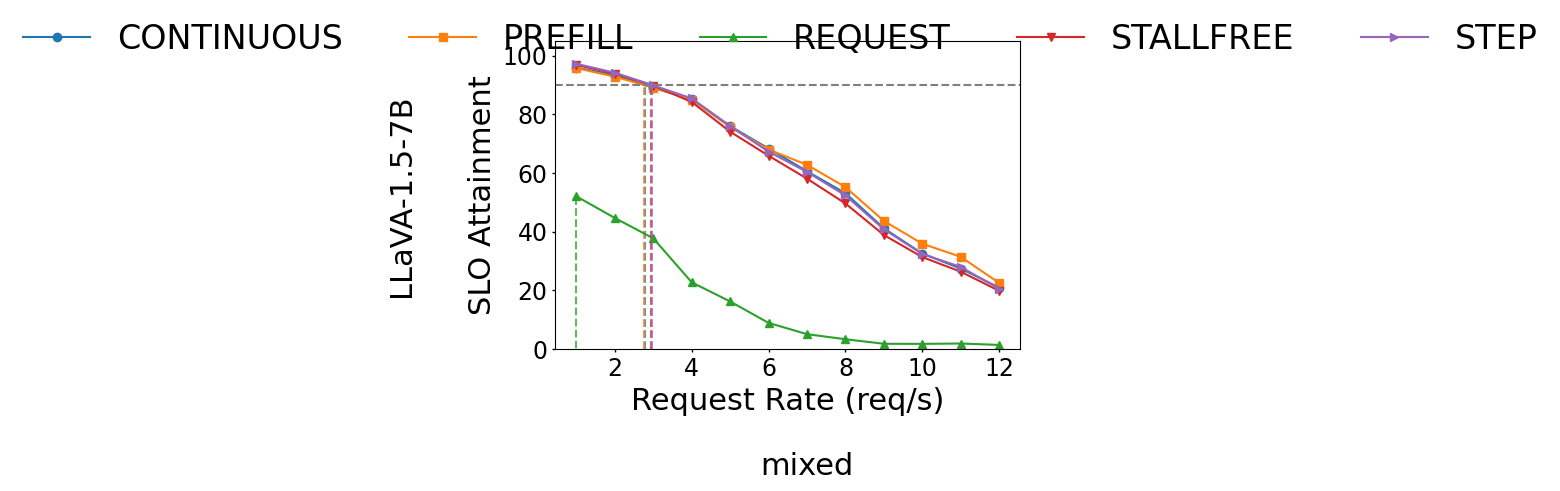

In [9]:
# visualize selected line
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

def draw_slo_vertical_line(x_values, y_values, slo_target, ax, **kwargs):
    cross_points = get_intersection_points(x_values, y_values, slo_target)
    if not cross_points:
        if y_values[0] < slo_target:
            ax.plot([x_values[0], x_values[0]], [-5, y_values[0]], **kwargs)
        elif y_values[-1] > slo_target:
            ax.plot([x_values[-1], x_values[-1]], [-5, y_values[-1]], **kwargs)
    for i, (x, y) in enumerate(cross_points):
        if i == len(cross_points) - 1:
            ax.plot([x, x], [0, y], **kwargs)

def smooth_curve(x, y, window_size=2):
    y_smooth = []
    for i in range(len(y)):
        start = max(0, i - window_size)
        end = min(i + window_size + 1, len(y))
        window = y[start:end]
        avg = sum(window) / len(window)
        y_smooth.append(avg)
    return x, y_smooth
    
for line_data in selected_line_data:
    if 'vllm' == line_data.method:
        line_data.method = 'vLLM-v1'
    elif 'vllm' in line_data.method:
        line_data.method = 'vLLM-v0'
    elif 'sglang' in line_data.method:
        line_data.method = 'SGLang'
    elif 'tgi' in line_data.method:
        line_data.method = 'TGI'
        
from tabulate import tabulate
table_headers = ["Model", "Dataset", "TTFT (s)", "TPOT (s)"]
table_data = []
for line_data in selected_line_data:
    if line_data.method == 'ours':
        # table_data.append((line_data.model, line_data.dataset, f"{line_data.ttft_slo.3f}/{line_data.tpot_slo:.3f}"))
        table_data.append((line_data.model, line_data.dataset, line_data.ttft_slo, line_data.tpot_slo))
        # , line_data.full_method_name.split('-')[-1].upper()
latex_table = tabulate(table_data, headers=table_headers, tablefmt="latex")
with open(os.path.join(tables_dir, "slo_settings.tex"), "w", encoding="utf-8") as f:
    f.write(latex_table)
print(tabulate(table_data, headers=table_headers, tablefmt='plain'))
    
# parameters
figure_name = "slo_attainment"
# figure_name = "batch_policy_abligation"

models = list({line_data.model for line_data in all_line_data})
model_id = {model: i for i, model in enumerate(models)}
id_model = {i: model for i, model in enumerate(models)}
print(f'model_id: {model_id}')
n_models = len(model_id)

datasets = list({line_data.dataset for line_data in all_line_data})
datasets = sorted(datasets)
dataset_id = {dataset: i for i, dataset in enumerate(datasets)}
id_dataset = {i: dataset for i, dataset in enumerate(datasets)}
print(f'dataset_id: {dataset_id}')
n_datasets = len(dataset_id)

methods = list({line_data.method for line_data in selected_line_data})
methods = sorted(methods) 
if "ours" in methods:
    methods.remove("ours")
    methods.insert(0, "ours")
method_id = {method: i for i, method in enumerate(methods)}
id_method = {i: method for i, method in enumerate(methods)}
print(f'method_id: {method_id}')
n_methods = len(methods)

# metric_id = {"slo_attainment": 0, "tpot_slo_attainment": 1, "ttft_slo_attainment": 2}
# metric_id_label = {0: "SLO Attainment", 1: "TPOT SLO Attainment",2: "TTFT SLO Attainment"}
metric_id = {"slo_attainment": 0}
metric_id_label = {0: "SLO Attainment"}
# metric_id = {"tpot_slo_attainment": 0}
# metric_id_label = {0: "TPOT SLO Attainment"}
id_metric = {id: metric for metric, id in metric_id.items()}
n_metrics = len(metric_id)

marker_list = ['o', 's', '^', 'v', '>', '<', 'd', 'p', '*', 'h', 'H', 'x', '+', '.', ',', '|', '_']
color_list = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

n_rows = n_models * n_metrics
n_cols = n_datasets
figsize=(6 * n_cols, 4 * n_rows)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
axes = np.array(axes).reshape(n_rows * n_cols)
def compute_ax_id(model_id: int, dataset_id: int, metric_id: int) -> int:
    axes_stride = (n_metrics * n_datasets, n_datasets, 1)
    ax_id = model_id * axes_stride[0] + metric_id * axes_stride[1] + dataset_id * axes_stride[2]
    return ax_id

for line_data in selected_line_data:
    line_data_model_id = model_id[line_data.model]
    line_data_dataset_id = dataset_id[line_data.dataset]
    line_data_method_id = method_id[line_data.method]
    color = color_list[line_data_method_id]
    marker = marker_list[line_data_method_id]
    
    for k, metric in id_metric.items():
        x = line_data.request_rates
        y = getattr(line_data, metric)
        x, y = smooth_curve(x, y)
        ax = axes[compute_ax_id(line_data_model_id, line_data_dataset_id, k)]
        ax.plot(x, y, color=color, marker=marker)
        draw_slo_vertical_line(x, y, slo_target=0.9, ax=ax, color=color, linestyle='--', alpha=0.75)
    
fontsize=22
for i in range(n_models):
    for j in range(n_datasets):
        for k in range(n_metrics):
            ax = axes[compute_ax_id(i, j, k)]
            ax.grid(False)
            ax.set_ylim(0, 1.05)
            
            formatter = FuncFormatter(lambda val, pos: f'{val * 100:.0f}')
            ax.yaxis.set_major_formatter(formatter)
            ax.axhline(y=0.9, color="gray", linestyle="--")

            metric = id_metric[k]
            if j == 0:
                ax.set_ylabel(metric_id_label[k], fontsize=fontsize)
                if figure_name != 'batch_policy_abligation':
                    ax.text(-0.30, 0.5, id_model[i], transform=ax.transAxes, ha='right', va='center', rotation=90, fontsize=fontsize)
            if i == n_models - 1 and k == n_metrics - 1:
                ax.set_xlabel('Request Rate (req/s)', fontsize=fontsize)
                if figure_name != 'batch_policy_abligation':
                    ax.text(7, -0.45, id_dataset[j], ha='center', va='bottom', fontsize=fontsize)
                
            for label in ax.get_xticklabels():
                label.set_fontsize(fontsize - 5)
            for label in ax.get_yticklabels():
                label.set_fontsize(fontsize - 5)
            ax.tick_params(axis='x', which='major', length=2, width=1, direction='out', grid_color='black', grid_alpha=1)
            ax.tick_params(axis='y', which='major', length=2, width=1, direction='out', grid_color='black', grid_alpha=1)
            ax.tick_params(which='both', bottom=True, top=False, left=True, right=False, labelbottom=True, labelleft=True, direction='out')
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                
legend_labels = [method for method, id in method_id.items()]
if figure_name == 'batch_policy_abligation':
    # used in batch policy abligation
    legend_label_map = {
        "8epd-w/o-stage-level-schedule" : "ours w/o hybrid EPD and sched", 
        "8epd" : "ours w/o hybrid EPD", 
    }
    for i, legend_label in enumerate(legend_labels):
        if legend_label in legend_label_map:
            legend_labels[i] = legend_label_map[legend_label]
            
if figure_name == 'batch_policy_abligation':
    legend_lines = [Line2D([0], [0], color=color_list[i], marker=marker_list[i]) for i in range(len(method_id))]
    legend_lines.append(Line2D([], [], color='none'))
    legend_labels.append('')
    def swap(l, i, j):
        l[i], l[j] = l[j], l[i]
        
    def swap_legend(i, j):
        swap(legend_lines, i, j)
        swap(legend_labels, i, j)
    swap_legend(2, 3)
    swap_legend(1, 2)
    legend_n_cols = 2
else:
    legend_lines = [Line2D([0], [0], color=color_list[i], marker=marker_list[i]) for i in range(len(method_id))]
    legend_n_cols = len(method_id)
    
fig.legend(
    legend_lines, 
    legend_labels, 
    loc='upper center', ncol=legend_n_cols, fontsize=fontsize + 2, frameon=False, bbox_to_anchor=(0.5, 1.0))

fig.savefig(os.path.join(figures_dir, f"{figure_name}.pdf"), bbox_inches="tight")

In [14]:
for line_data in selected_line_data:
    if line_data.model != 'LLaVA-NeXT-7B':
        continue
    print(line_data.method, line_data.dataset, line_data.avg_ttft)

vLLM-v0 VizWiz [0.21180689036846162, 0.2152613808400929, 0.34300905130803583, 0.309441355150193, 0.26454564440995454, 0.5277001129463315, 0.3819646748315011, 0.9035664029652253, 0.5326461351787051, 1.0206212161295116, 0.7648611046373844, 3.570814627952253]
vLLM-v1 VizWiz [0.23290066309273244, 0.2478901021182537, 0.40475513817121583, 0.4065575103741139, 0.2875744366273284, 0.5298490190568069, 0.4487915249009218, 1.1272706439485773, 0.5860371594420738, 0.9599112179502844, 0.7965154151178219, 2.2734124368677535]
ours VizWiz [0.33498120135627685, 0.35621785338522877, 0.4166052577861895, 0.5512275837747187, 0.5581559013565979, 0.6033912878600193, 0.7549264475220828, 0.7932557429643875, 0.9956412709728404, 1.450297940375012, 2.164452962649886, 1.6114086987499479]
TGI VizWiz [60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]
vLLM-v0 TextVQA [0.14916892684996128, 0.15962197901681066, 0.1650962942590316, 0.19514586152508856, 0.15965232219547032, 0.20182747108240923, 0.17985508503126246, 0.2610914